In [151]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [152]:
data = pd.read_csv('tips.csv')
data.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [153]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    str    
 3   smoker      244 non-null    str    
 4   day         244 non-null    str    
 5   time        244 non-null    str    
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), str(4)
memory usage: 13.5 KB


In [154]:
data.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [ ]:
data.shape

In [ ]:
data.isnull().sum()

C:\Users\Admin\AppData\Local\Temp\ipykernel_464\3798198533.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data.total_bill, color="b", ax=axes[0])
C:\Users\Admin\AppData\Local\Temp\ipykernel_464\3798198533.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data.tip, color="r", ax=axes[1])


<Axes: xlabel='tip', ylabel='Density'>

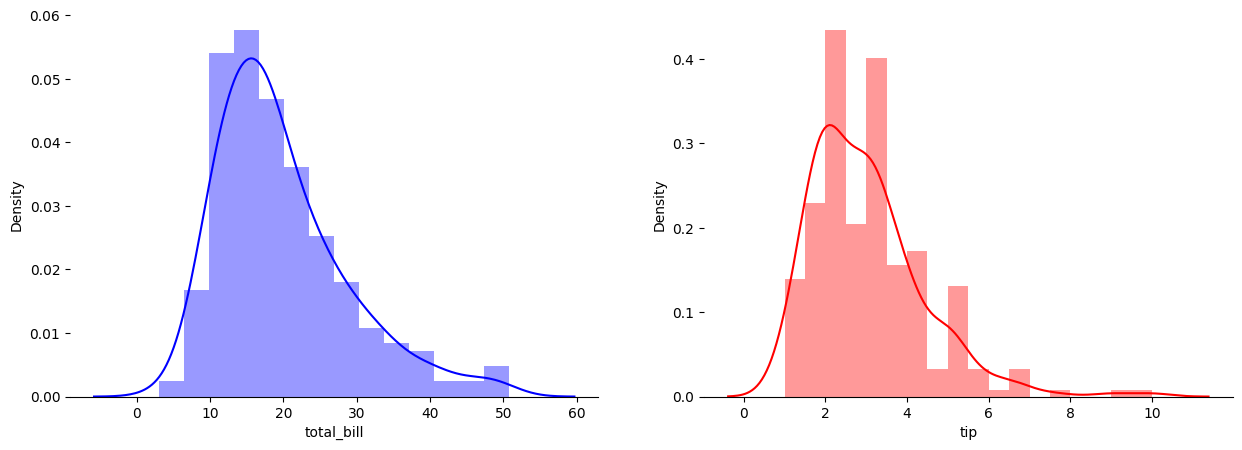

In [157]:
import seaborn as sns
f,axes = plt.subplots(1,2,figsize=(15,5),sharex=False)
sns.despine(left=True)
sns.distplot(data.total_bill, color="b", ax=axes[0])

sns.distplot(data.tip, color="r", ax=axes[1])

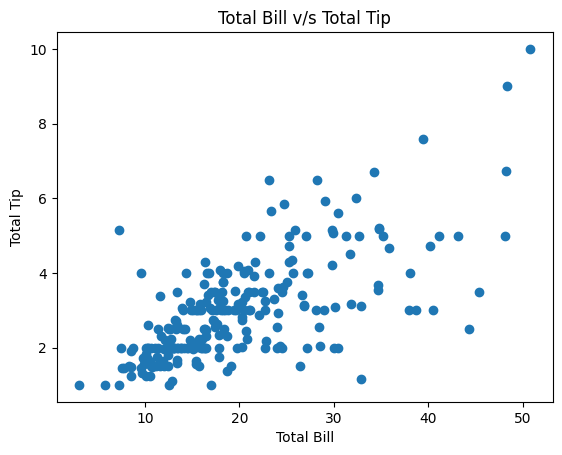

In [158]:
plt.scatter(data['total_bill'],data['tip'])
plt.title('Total Bill v/s Total Tip')
plt.xlabel('Total Bill')
plt.ylabel('Total Tip')
plt.show()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    str    
 3   smoker      244 non-null    str    
 4   day         244 non-null    str    
 5   time        244 non-null    str    
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), str(4)
memory usage: 13.5 KB
Axes(0.125,0.11;0.775x0.77)
smoker
No     151
Yes     93
Name: count, dtype: int64
day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64
time
Dinner    176
Lunch      68
Name: count, dtype: int64
size
2    156
3     38
4     37
5      5
1      4
6      4
Name: count, dtype: int64


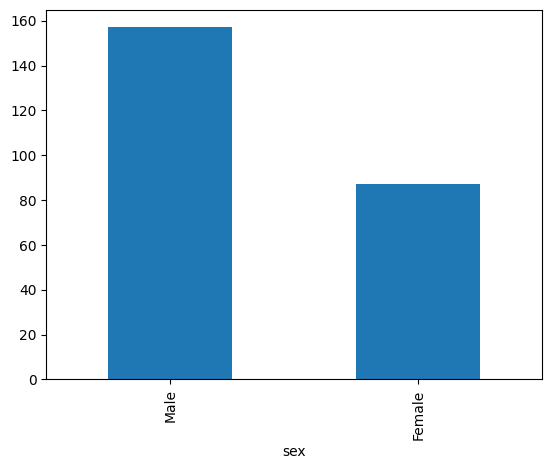

: 

In [ ]:
data.info()
print(data['sex'].value_counts().plot(kind='bar'))
print(data['smoker'].value_counts())
print(data['day'].value_counts())
print(data['time'].value_counts())
print(data['size'].value_counts())


In [160]:
data['smoker']

0       No
1       No
2       No
3       No
4       No
      ... 
239     No
240    Yes
241    Yes
242     No
243     No
Name: smoker, Length: 244, dtype: str

In [161]:
from sklearn.preprocessing import StandardScaler,LabelEncoder
le = LabelEncoder()
for col in data.columns:
    if data[col].dtype == 'str':
        data[col] = le.fit_transform(data[col])
data.head()


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,0,0,2,0,2
1,10.34,1.66,1,0,2,0,3
2,21.01,3.50,1,0,2,0,3
3,23.68,3.31,1,0,2,0,2
4,24.59,3.61,0,0,2,0,4


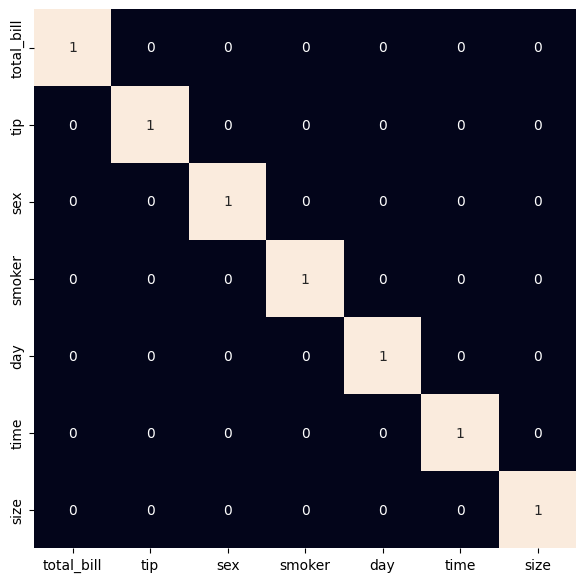

In [162]:
plt.figure(figsize=(7,7))
sns.heatmap(data.corr()> 0.7,annot = True,cbar = False)
plt.show()

In [163]:
features = data.drop('tip',axis=1)
target = data['tip']
from sklearn.model_selection import train_test_split
X_train,X_val,y_train,y_val=train_test_split(features,target,test_size=0.05,random_state=22)
X_train.shape,X_val.shape


((231, 6), (13, 6))

In [164]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [168]:
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.metrics import mean_absolute_error as mae
from sklearn.linear_model import LinearRegression
models = [LinearRegression(), RandomForestRegressor(), AdaBoostRegressor()]
for i in range(3):
  models[i].fit(X_train, y_train)
  print(f'{models[i]}:')
  pred_train = models[i].predict(X_train)
  print('Training Accuracy:', mae(y_train, pred_train))
  pred_val = models[i].predict(X_val)
  print('Validation Accuracy:', mae(y_val, pred_val))
  print()
           

LinearRegression():
Training Accuracy: 0.7314185712046005
Validation Accuracy: 0.7862933546714855

RandomForestRegressor():
Training Accuracy: 0.28390000000000004
Validation Accuracy: 0.6664846153846151

AdaBoostRegressor():
Training Accuracy: 0.7107906748050971
Validation Accuracy: 0.5586407380589257

